# 09 — Order Volume Forecasting

This notebook explores demand forecasting as a complement to risk prediction.

**Why forecasting matters:**
- Knowing WHEN orders will spike helps with capacity planning
- If we predict high order volume + many high-risk orders, we need more
  delivery resources ready
- This is directly relevant to food-delivery operations where demand
  fluctuates by time of day, day of week, and season

**Approach:**
1. Aggregate daily order volumes from the dataset
2. Start with simple baselines (moving average, historical average)
3. Try Holt-Winters exponential smoothing
4. Evaluate with MAE and RMSE

**Honest caveat:** This dataset isn't a real-time operational dataset, so
the forecasting patterns may not reflect actual live conditions. This section
demonstrates the methodology.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

## 9.1 Load Data and Create Time Series

In [2]:
df = pd.read_csv("../data/processed/cleaned_with_dates.csv")
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])

print(f"Date range: {df['order date (DateOrders)'].min()} to {df['order date (DateOrders)'].max()}")
print(f"Total orders: {len(df):,}")

Date range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00
Total orders: 180,519


In [3]:
# Aggregate daily order volume
daily_orders = (
    df.groupby(df["order date (DateOrders)"].dt.date)
    .agg(
        order_count=("Late_delivery_risk", "count"),
        late_count=("Late_delivery_risk", "sum"),
        avg_sales=("Sales", "mean")
    )
    .reset_index()
)

daily_orders.columns = ["date", "order_count", "late_count", "avg_sales"]
daily_orders["date"] = pd.to_datetime(daily_orders["date"])
daily_orders = daily_orders.sort_values("date").set_index("date")
daily_orders["late_rate"] = daily_orders["late_count"] / daily_orders["order_count"]

print(f"Daily aggregation: {len(daily_orders)} days")
print(f"Average daily orders: {daily_orders['order_count'].mean():.0f}")
daily_orders.head()

Daily aggregation: 1127 days
Average daily orders: 160


,order_count,late_count,avg_sales,late_rate
date,,,,
2015-01-01,168,91,195.274349,0.541667
2015-01-02,154,64,193.624744,0.415584
2015-01-03,179,105,203.065423,0.586592
2015-01-04,191,100,187.115030,0.523560
2015-01-05,160,95,194.174441,0.593750


## 9.2 Visualize Order Patterns

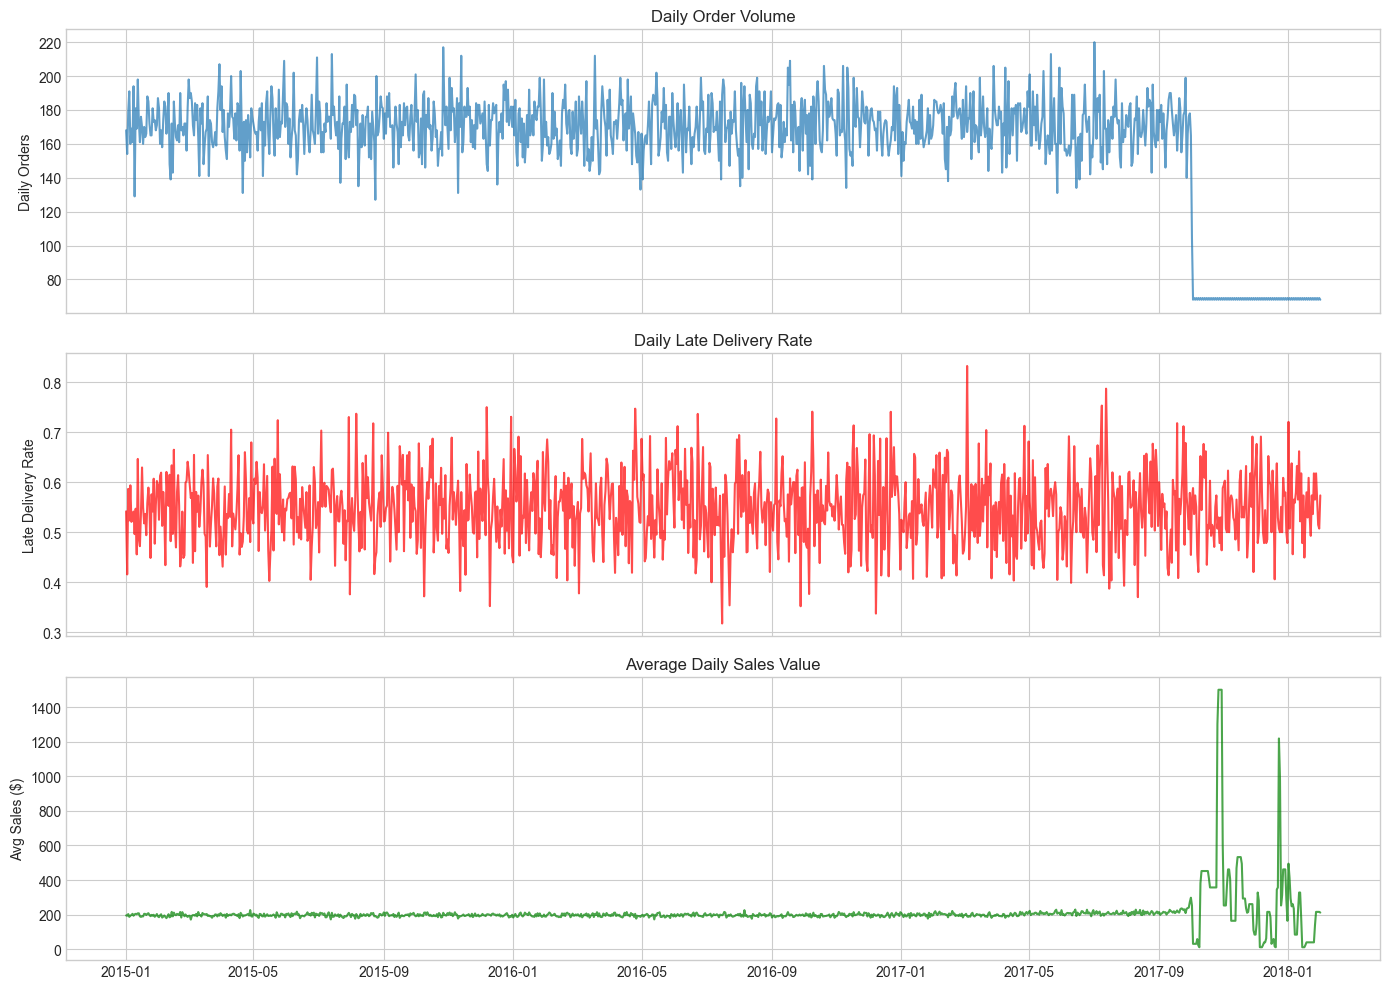

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(daily_orders.index, daily_orders["order_count"], alpha=0.7)
axes[0].set_ylabel("Daily Orders")
axes[0].set_title("Daily Order Volume")

axes[1].plot(daily_orders.index, daily_orders["late_rate"], alpha=0.7, color="red")
axes[1].set_ylabel("Late Delivery Rate")
axes[1].set_title("Daily Late Delivery Rate")

axes[2].plot(daily_orders.index, daily_orders["avg_sales"], alpha=0.7, color="green")
axes[2].set_ylabel("Avg Sales ($)")
axes[2].set_title("Average Daily Sales Value")

plt.tight_layout()
plt.show()

## 9.3 Weekly Aggregation

Daily data can be noisy. Let's also look at weekly patterns.

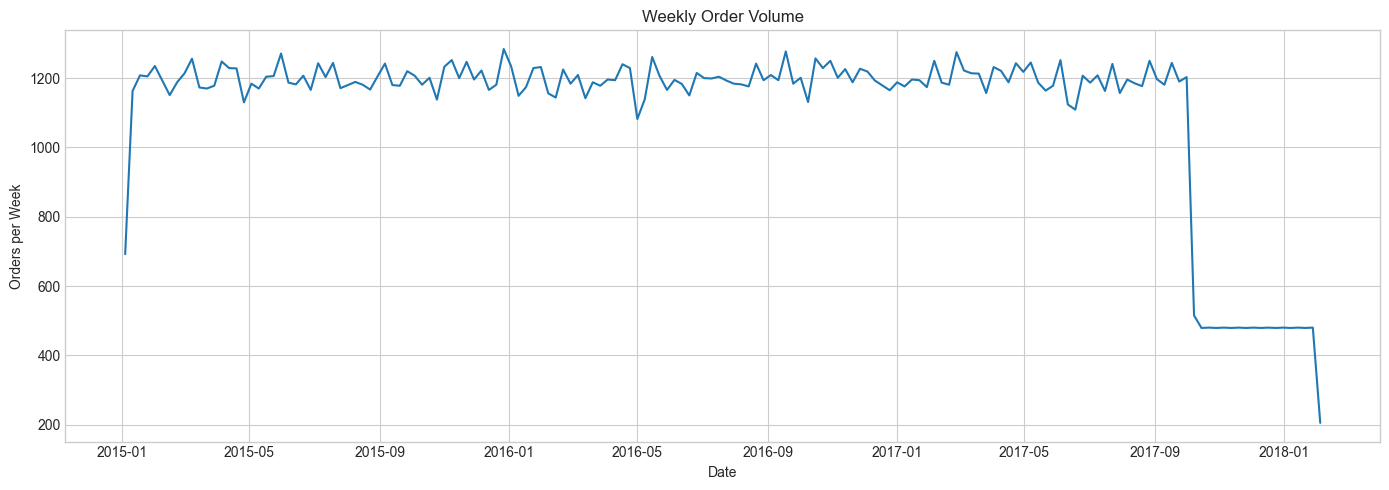

In [5]:
weekly_orders = daily_orders["order_count"].resample("W").sum()

plt.figure(figsize=(14, 5))
plt.plot(weekly_orders.index, weekly_orders.values)
plt.title("Weekly Order Volume")
plt.ylabel("Orders per Week")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 9.4 Day-of-Week Pattern

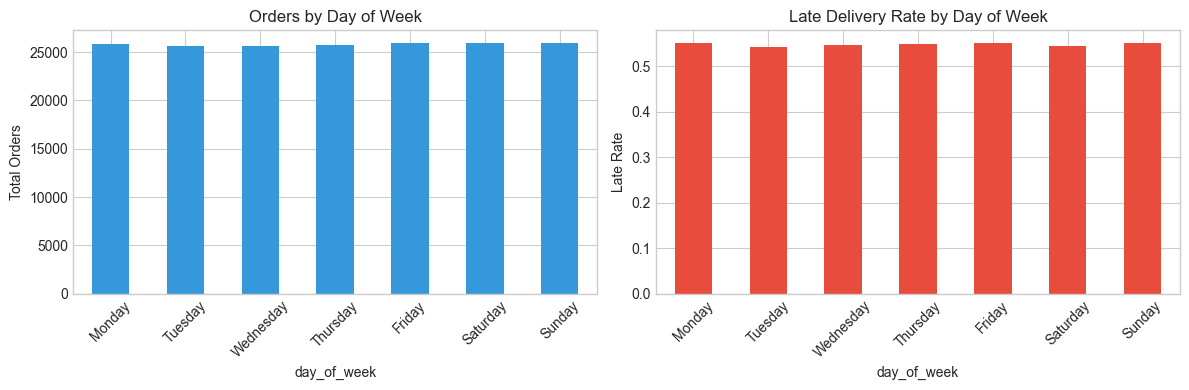

In [6]:
df["day_of_week"] = df["order date (DateOrders)"].dt.day_name()

dow_orders = df.groupby("day_of_week")["Late_delivery_risk"].agg(["count", "mean"])
dow_orders.columns = ["order_count", "late_rate"]

# Reorder days
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_orders = dow_orders.reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dow_orders["order_count"].plot(kind="bar", ax=axes[0], color="#3498db")
axes[0].set_title("Orders by Day of Week")
axes[0].set_ylabel("Total Orders")
axes[0].tick_params(axis="x", rotation=45)

dow_orders["late_rate"].plot(kind="bar", ax=axes[1], color="#e74c3c")
axes[1].set_title("Late Delivery Rate by Day of Week")
axes[1].set_ylabel("Late Rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 9.5 Train/Test Split for Forecasting

We use the last 20% of the time series as the test set.
This is different from random splitting — for time series, we must
preserve temporal order.

Training: 129 weeks
Test: 33 weeks


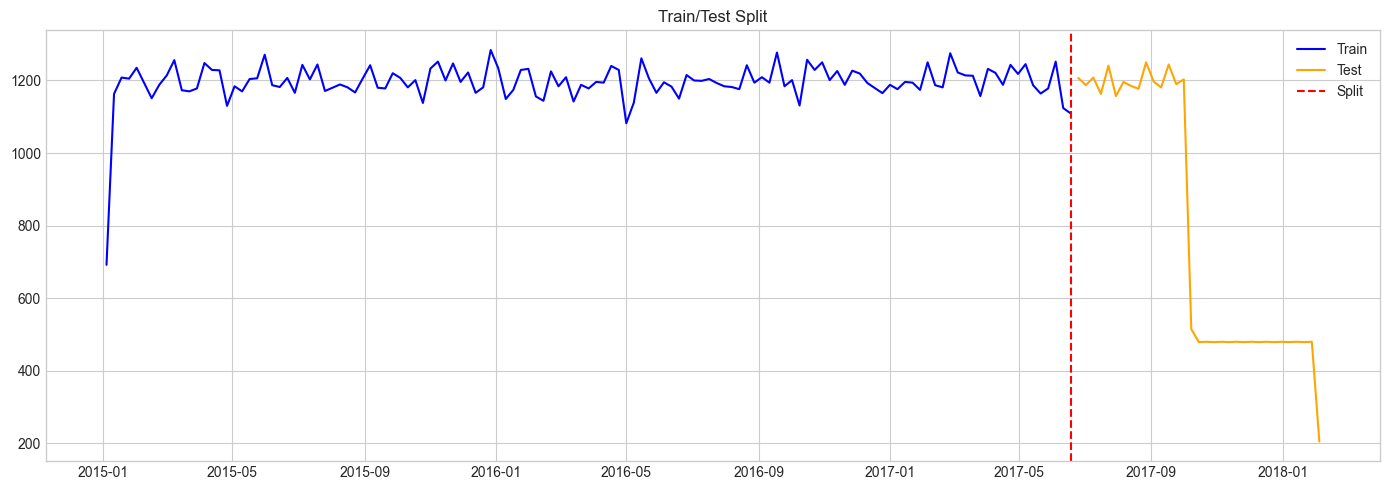

In [7]:
split_point = int(len(weekly_orders) * 0.8)

train_ts = weekly_orders[:split_point]
test_ts = weekly_orders[split_point:]

print(f"Training: {len(train_ts)} weeks")
print(f"Test: {len(test_ts)} weeks")

plt.figure(figsize=(14, 5))
plt.plot(train_ts.index, train_ts.values, label="Train", color="blue")
plt.plot(test_ts.index, test_ts.values, label="Test", color="orange")
plt.axvline(x=train_ts.index[-1], color="red", linestyle="--", label="Split")
plt.title("Train/Test Split")
plt.legend()
plt.tight_layout()
plt.show()

## 9.6 Baseline Models

In [8]:
# Baseline 1: Historical average
historical_avg = train_ts.mean()
pred_avg = pd.Series([historical_avg] * len(test_ts), index=test_ts.index)

mae_avg = mean_absolute_error(test_ts, pred_avg)
rmse_avg = np.sqrt(mean_squared_error(test_ts, pred_avg))

print(f"Historical Average: MAE={mae_avg:.0f}, RMSE={rmse_avg:.0f}")

# Baseline 2: 4-week moving average (use last 4 weeks of train for initial prediction)
ma_window = 4

# For each test point, use the mean of the previous ma_window observations
pred_ma = []
history = list(train_ts.values)

for i in range(len(test_ts)):
    ma_pred = np.mean(history[-ma_window:])
    pred_ma.append(ma_pred)
    history.append(test_ts.values[i])  # Add actual value for next prediction

pred_ma = pd.Series(pred_ma, index=test_ts.index)
mae_ma = mean_absolute_error(test_ts, pred_ma)
rmse_ma = np.sqrt(mean_squared_error(test_ts, pred_ma))

print(f"4-Week Moving Average: MAE={mae_ma:.0f}, RMSE={rmse_ma:.0f}")

Historical Average: MAE=407, RMSE=541
4-Week Moving Average: MAE=76, RMSE=179


## 9.7 Holt-Winters Exponential Smoothing

Exponential smoothing captures trend and seasonality. We try additive
and multiplicative variants.

In [9]:
# Holt-Winters with additive trend
try:
    hw_model = ExponentialSmoothing(
        train_ts,
        trend="add",
        seasonal=None,  # Weekly data may not have strong seasonality
        initialization_method="estimated"
    ).fit(optimized=True)
    
    pred_hw = hw_model.forecast(len(test_ts))
    mae_hw = mean_absolute_error(test_ts, pred_hw)
    rmse_hw = np.sqrt(mean_squared_error(test_ts, pred_hw))
    
    print(f"Holt-Winters (additive): MAE={mae_hw:.0f}, RMSE={rmse_hw:.0f}")
    hw_success = True
except Exception as e:
    print(f"Holt-Winters failed: {e}")
    print("Falling back to simple exponential smoothing")
    hw_success = False

Holt-Winters (additive): MAE=417, RMSE=553


## 9.8 Forecast Comparison

Forecast Comparison:
               Method        MAE       RMSE
   Historical Average 406.883486 540.533275
4-Week Moving Average  75.818182 178.509772
         Holt-Winters 417.478262 552.881341


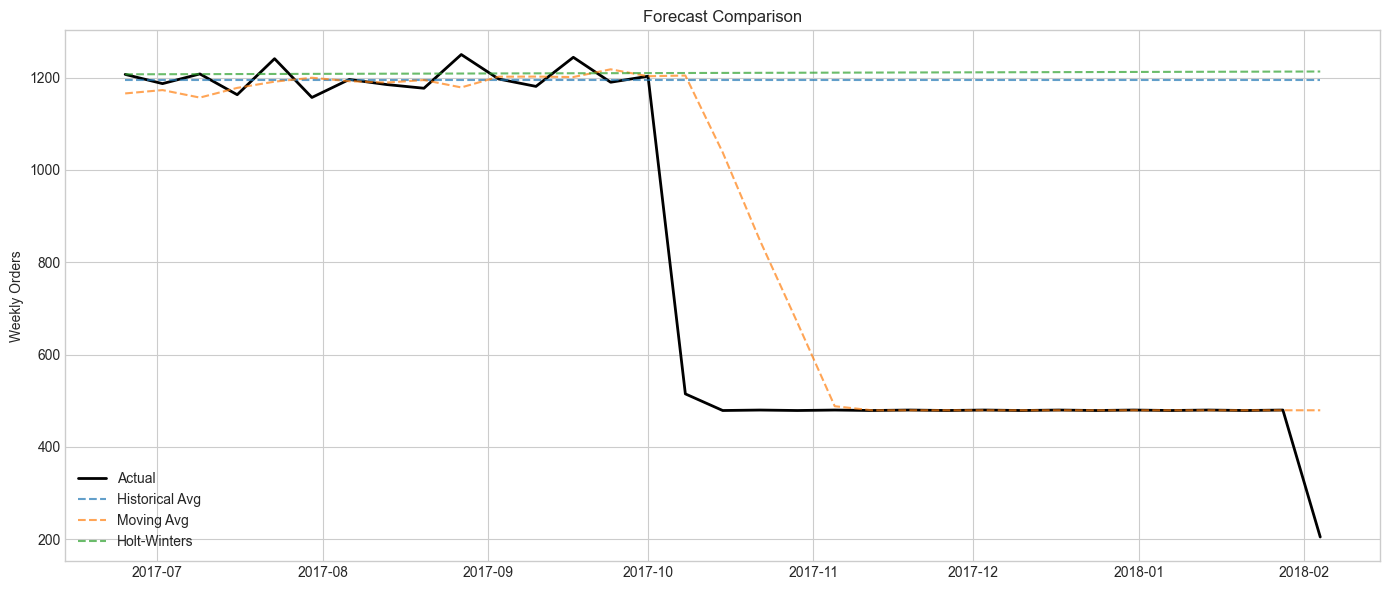

In [10]:
# Compare all methods
results = pd.DataFrame({
    "Method": ["Historical Average", "4-Week Moving Average"],
    "MAE": [mae_avg, mae_ma],
    "RMSE": [rmse_avg, rmse_ma]
})

if hw_success:
    results = pd.concat([results, pd.DataFrame({
        "Method": ["Holt-Winters"],
        "MAE": [mae_hw],
        "RMSE": [rmse_hw]
    })], ignore_index=True)

print("Forecast Comparison:")
print("=" * 50)
print(results.to_string(index=False))

# Visualize predictions
plt.figure(figsize=(14, 6))
plt.plot(test_ts.index, test_ts.values, "k-", label="Actual", linewidth=2)
plt.plot(test_ts.index, pred_avg.values, "--", label="Historical Avg", alpha=0.7)
plt.plot(test_ts.index, pred_ma.values, "--", label="Moving Avg", alpha=0.7)
if hw_success:
    plt.plot(test_ts.index, pred_hw.values, "--", label="Holt-Winters", alpha=0.7)
plt.title("Forecast Comparison")
plt.ylabel("Weekly Orders")
plt.legend()
plt.tight_layout()
plt.show()

## Summary

**What we found:**
- Order volume shows temporal patterns (day-of-week effects, potential trends)
- Simple baselines provide a reasonable starting point
- Holt-Winters can capture trend if present in the data

**Operational relevance:**
- If we can predict that next week will have high order volume, AND our risk
  model identifies many of those orders as high-risk, we can proactively
  allocate more delivery resources
- The same approach applies to food delivery: predicting lunch/dinner rush
  volumes helps optimize rider allocation

**Limitations:**
- This dataset is not real-time operational data
- The forecasting is at a coarse weekly granularity
- In practice, food delivery forecasting would use much more granular data
  (hourly, by zone, by restaurant)

**Next step:** A/B test simulation